In [ ]:
import zipfile

zip_ref = zipfile.ZipFile('leaf.zip', 'r')
zip_ref.extractall('/content/dataset')
zip_ref.close()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving leaf.zip to leaf.zip


In [ ]:
import os
os.listdir('/content/dataset')

['ReadMe.pdf', 'RGB', 'BW', 'leaf.csv']

In [ ]:
os.listdir('/content/dataset/RGB')[:10]

['18. Papaver sp',
 '15. Populus alba',
 '5. Quercus robur',
 '35. Magnolia grandiflora',
 '31. Podocarpus sp',
 '27. Ilex perado ssp azorica',
 '21. Fraxinus sp',
 '25. Arisarum vulgare',
 '22. Primula vulgaris',
 '16. Acer negundo']

In [ ]:
import pandas as pd
data = pd.read_csv('/content/dataset/leaf.csv')
data.head()

,1,1.1,0.72694,1.4742,0.32396,0.98535,1.2,0.83592,0.0046566,0.0039465,0.04779,0.12795,0.016108,0.0052323,0.00027477,1.1756
0,1,2,0.74173,1.5257,0.36116,0.98152,0.99825,0.79867,0.005242,0.005002,0.024160,0.090476,0.008119,0.002708,0.000075,0.69659
1,1,3,0.76722,1.5725,0.38998,0.97755,1.00000,0.80812,0.007457,0.010121,0.011897,0.057445,0.003289,0.000921,0.000038,0.44348
2,1,4,0.73797,1.4597,0.35376,0.97566,1.00000,0.81697,0.006877,0.008607,0.015950,0.065491,0.004271,0.001154,0.000066,0.58785
3,1,5,0.82301,1.7707,0.44462,0.97698,1.00000,0.75493,0.007428,0.010042,0.007938,0.045339,0.002051,0.000560,0.000024,0.34214
4,1,6,0.72997,1.4892,0.34284,0.98755,1.00000,0.84482,0.004945,0.004451,0.010487,0.058528,0.003414,0.001125,0.000025,0.34068


(np.float64(-0.5), np.float64(719.5), np.float64(959.5), np.float64(-0.5))

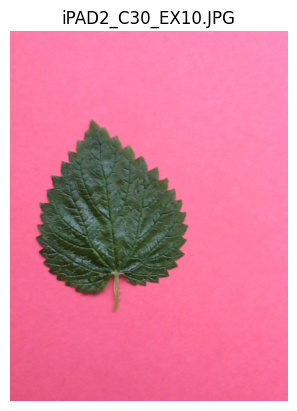

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

folder = '/content/dataset/RGB/30. Urtica dioica'
image_name = os.listdir(folder)[0]

img = cv2.imread(os.path.join(folder, image_name))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(image_name)
plt.axis('off')

(np.float64(-0.5), np.float64(719.5), np.float64(959.5), np.float64(-0.5))

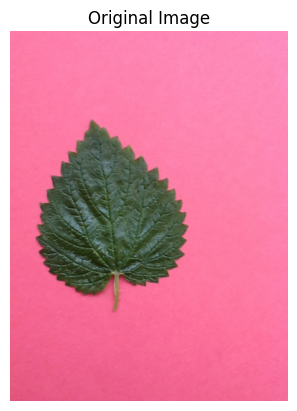

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

folder = '/content/dataset/RGB/30. Urtica dioica'
image_name = os.listdir(folder)[0]

img = cv2.imread(os.path.join(folder, image_name))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

(np.float64(-0.5), np.float64(719.5), np.float64(959.5), np.float64(-0.5))

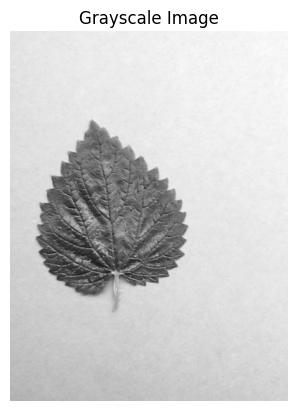

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')

(np.float64(-0.5), np.float64(719.5), np.float64(959.5), np.float64(-0.5))

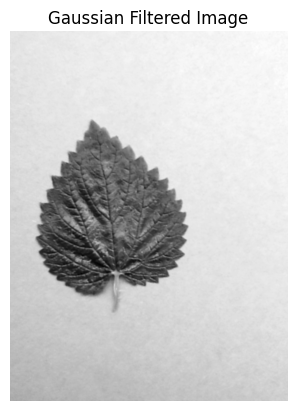

In [ ]:
blur = cv2.GaussianBlur(gray, (5,5), 0)

plt.imshow(blur, cmap='gray')
plt.title("Gaussian Filtered Image")
plt.axis('off')

(np.float64(-0.5), np.float64(719.5), np.float64(959.5), np.float64(-0.5))

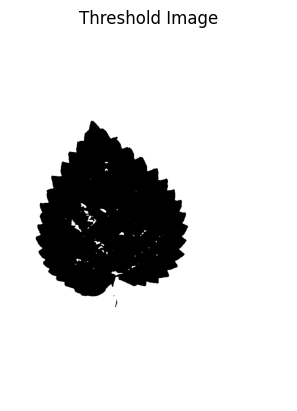

In [ ]:
_, thresh = cv2.threshold(blur, 120, 255, cv2.THRESH_BINARY)

plt.imshow(thresh, cmap='gray')
plt.title("Threshold Image")
plt.axis('off')

(np.float64(-0.5), np.float64(719.5), np.float64(959.5), np.float64(-0.5))

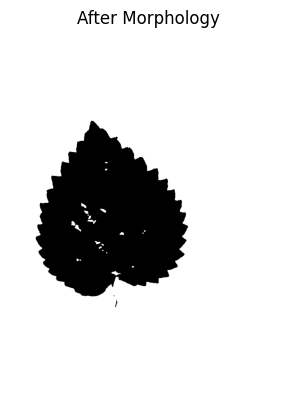

In [ ]:
import numpy as np

kernel = np.ones((3,3), np.uint8)

erosion = cv2.erode(thresh, kernel, iterations=1)
dilation = cv2.dilate(erosion, kernel, iterations=1)

plt.imshow(dilation, cmap='gray')
plt.title("After Morphology")
plt.axis('off')

(np.float64(-0.5), np.float64(719.5), np.float64(959.5), np.float64(-0.5))

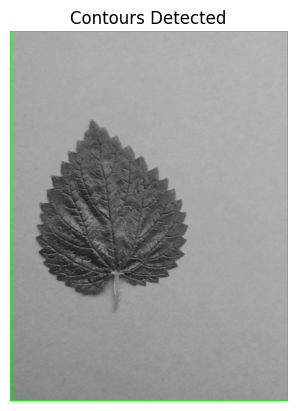

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# use previous processed image (dilation)
contours, _ = cv2.findContours(dilation, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# draw contours
contour_img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
cv2.drawContours(contour_img, contours, -1, (0,255,0), 2)

plt.imshow(contour_img)
plt.title("Contours Detected")
plt.axis('off')

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

base_path = '/content/dataset/RGB'

data_list = []

for folder_name in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder_name)

    if not os.path.isdir(folder_path):
        continue

    for image_name in os.listdir(folder_path):
        image_path = os.path.join(folder_path, image_name)

        img = cv2.imread(image_path)
        if img is None:
            continue

        # -------- Preprocessing --------
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray, (5,5), 0)

        thresh = cv2.adaptiveThreshold(
            blur, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV,
            11, 2
        )

        kernel = np.ones((5,5), np.uint8)
        morph = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

        # -------- Contours --------
        contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(contours) == 0:
            continue

        #  ONLY LARGEST CONTOUR
        cnt = max(contours, key=cv2.contourArea)

        area = cv2.contourArea(cnt)

        # better filtering
        if area < 500:
            continue

        perimeter = cv2.arcLength(cnt, True)

        x,y,w,h = cv2.boundingRect(cnt)
        aspect_ratio = float(w)/h
        extent = area/(w*h)

        circularity = (4 * np.pi * area) / (perimeter * perimeter + 1e-5)

        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity = float(area) / (hull_area + 1e-5)

        eq_diameter = np.sqrt(4 * area / np.pi)
        mean_intensity = np.mean(gray)

        # 🔥 COLOR FEATURES (VERY IMPORTANT)
        mean_r = np.mean(img[:,:,2])
        mean_g = np.mean(img[:,:,1])
        mean_b = np.mean(img[:,:,0])

        data_list.append([
            area, perimeter, aspect_ratio, extent,
            circularity, solidity, eq_diameter, mean_intensity,
            mean_r, mean_g, mean_b,
            folder_name
        ])

# -------- Create DataFrame --------
df = pd.DataFrame(data_list, columns=[
    'Area','Perimeter','AspectRatio','Extent',
    'Circularity','Solidity','EqDiameter','MeanIntensity',
    'MeanR','MeanG','MeanB',
    'Label'
])

print("Dataset size:", df.shape)
df.head()

Dataset size: (443, 12)


,Area,Perimeter,AspectRatio,Extent,Circularity,Solidity,EqDiameter,MeanIntensity,MeanR,MeanG,MeanB,Label
0,22225.5,3164.774938,0.491525,0.090207,0.027885,0.203755,168.221240,148.274248,220.313853,116.663031,122.541947,18. Papaver sp
1,29016.0,3120.174869,0.296621,0.153230,0.037453,0.285878,192.209049,139.600952,232.320312,98.338416,109.047001,18. Papaver sp
2,32860.5,2754.476386,0.311606,0.266543,0.054426,0.446647,204.546543,142.431651,231.603631,103.133005,111.102418,18. Papaver sp
3,19098.5,2957.765710,0.205707,0.131267,0.027434,0.209521,155.938980,144.288015,235.225563,104.776991,109.278886,18. Papaver sp
4,10355.0,2254.964632,0.300169,0.098101,0.025591,0.171883,114.823323,142.028905,210.763848,109.840547,127.608659,18. Papaver sp


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# -------- Features & Labels --------
X = df.drop('Label', axis=1)
y = df['Label']

# -------- Scaling --------
scaler = StandardScaler()
X = scaler.fit_transform(X)

# -------- Model (Optimized) --------
model = KNeighborsClassifier(
    n_neighbors=7,          # better than 3
    weights='distance',    # important
    metric='euclidean'     # better for this data
)

# -------- Train --------
model.fit(X, y)

print("Model trained successfully")

Model trained successfully


In [ ]:
from sklearn.metrics import accuracy_score

pred = model.predict(X)
accuracy = accuracy_score(y, pred)

print("Training Accuracy:", accuracy)

Training Accuracy: 1.0


Saving iPAD2_C16_EX05.JPG to iPAD2_C16_EX05.JPG


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


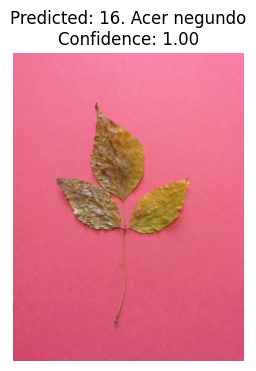


Similar Images:


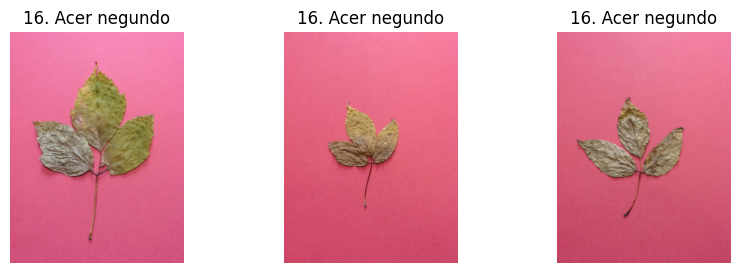


Model Accuracy: 1.0


In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# -------- Upload Image --------
uploaded = files.upload()

image_name = list(uploaded.keys())[0]
img = cv2.imread(image_name)

# -------- Preprocessing --------
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

thresh = cv2.adaptiveThreshold(
    blur, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11, 2
)

kernel = np.ones((5,5), np.uint8)
morph = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

# -------- Contours --------
contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

prediction = "No leaf detected"
confidence = 0

if len(contours) > 0:
    cnt = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(cnt)

    if area > 500:
        perimeter = cv2.arcLength(cnt, True)

        x,y,w,h = cv2.boundingRect(cnt)
        aspect_ratio = float(w)/h
        extent = area/(w*h)

        circularity = (4 * np.pi * area) / (perimeter * perimeter + 1e-5)

        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity = float(area) / (hull_area + 1e-5)

        eq_diameter = np.sqrt(4 * area / np.pi)
        mean_intensity = np.mean(gray)

        # 🔥 COLOR FEATURES
        mean_r = np.mean(img[:,:,2])
        mean_g = np.mean(img[:,:,1])
        mean_b = np.mean(img[:,:,0])

        test_feature = scaler.transform([[
            area, perimeter, aspect_ratio, extent,
            circularity, solidity, eq_diameter, mean_intensity,
            mean_r, mean_g, mean_b
        ]])

        probs = model.predict_proba(test_feature)
        prediction = model.classes_[np.argmax(probs)]
        confidence = np.max(probs)

# -------- Show Input --------
plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Predicted: {prediction}\nConfidence: {confidence:.2f}")
plt.axis('off')
plt.show()

# -------- Show Similar Images --------
print("\nSimilar Images:")

folder_path = os.path.join('/content/dataset/RGB', prediction)

if os.path.exists(folder_path):
    images = os.listdir(folder_path)[:3]

    plt.figure(figsize=(10,3))

    for i, img_name in enumerate(images):
        path = os.path.join(folder_path, img_name)
        simg = cv2.imread(path)

        plt.subplot(1,3,i+1)
        plt.imshow(cv2.cvtColor(simg, cv2.COLOR_BGR2RGB))
        plt.title(prediction)
        plt.axis('off')

    plt.show()

print("\nModel Accuracy:", accuracy)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')